✅ Dataset generate ho gaya: movie_vast_dataset.csv
🚀 Model training shuru ho rahi hai...

📊 --- DETAILED MODEL PERFORMANCE ---
Accuracy:  86.30%
Precision: 0.85 (Model kitna 'sure' hai hit predict karne mein)
Recall:    0.94 (Kitni actual hits model ne pakdi hain)
F1 Score:  0.89 (Precision aur Recall ka balance)


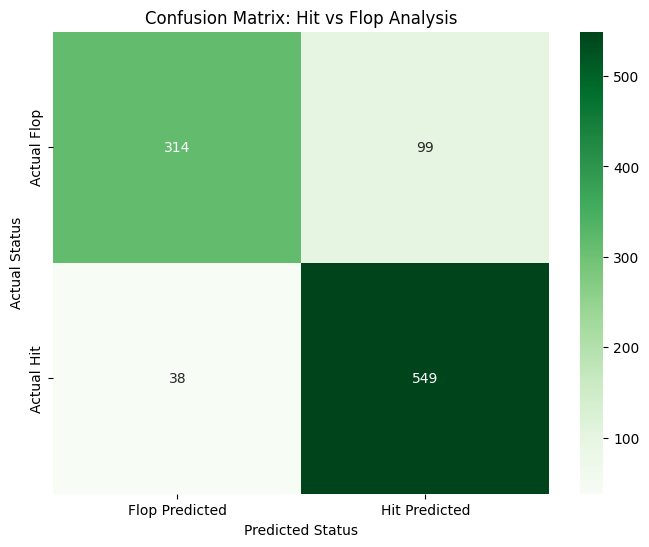


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82       413
           1       0.85      0.94      0.89       587

    accuracy                           0.86      1000
   macro avg       0.87      0.85      0.85      1000
weighted avg       0.87      0.86      0.86      1000


💾 Success: Model aur Encoders save ho gaye hain!


In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    f1_score, 
    accuracy_score, 
    precision_score, 
    recall_score
)
from sklearn.preprocessing import LabelEncoder

# --- STEP 1: VAST DATA GENERATION LOGIC ---
# Isme 200+ directors aur 150+ actors shamil hain
def generate_vast_movie_data(n=5000):
    np.random.seed(42)
    
    # Pools of Unique Names (Animation, Hollywood, Bollywood)
    actors = [
        'Robin Williams', 'Mark Hamill', 'James Earl Jones', 'Morgan Freeman', 'Tom Hanks', 
        'Jack Black', 'Scarlett Johansson', 'Samuel L. Jackson', 'Keith David', 'J.K. Simmons', 
        'Patrick Warburton', 'Vin Diesel', 'Danny DeVito', 'Steve Carell', 'Mike Myers', 
        'Antonio Banderas', 'Eddie Murphy', 'Brad Pitt', 'Angelina Jolie', 'Will Smith', 
        'Cameron Diaz', 'Chris Rock', 'Ben Stiller', 'Reese Witherspoon', 'Matthew McConaughey', 
        'Seth Rogen', 'Bill Hader', 'Kristen Wiig', 'Amy Poehler', 'Tina Fey', 'Alan Tudyk', 
        'Hank Azaria', 'Dan Castellaneta', 'Seth MacFarlane', 'John DiMaggio', 'Phil LaMarr', 
        'Tara Strong', 'Cree Summer', 'Grey DeLisle', 'Clancy Brown', 'Katey Sagal', 'Seth Green', 
        'Mila Kunis', 'Alex Borstein', 'Will Arnett', 'Elizabeth Banks', 'Patton Oswalt', 
        'Maya Rudolph', 'Fred Armisen', 'Nick Kroll', 'Jenny Slate', 'Jason Mantzoukas', 
        'Stephanie Beatriz', 'Awkwafina', 'John Leguizamo', 'Dwayne Johnson', 'Kevin Hart', 
        'Hailee Steinfeld', 'Tom Holland', 'Chris Pratt', 'Zendaya', 'Anna Kendrick', 
        'Justin Timberlake', 'James Corden', 'Rebel Wilson', 'Josh Gad', 'Kristen Bell', 
        'Idina Menzel', 'Jonathan Groff', 'Sterling K. Brown', 'Willem Dafoe', 'Gary Oldman', 
        'Benedict Cumberbatch', 'Tom Hiddleston', 'Cate Blanchett', 'Tilda Swinton', 'Ian McKellen', 
        'Patrick Stewart', 'Hugo Weaving', 'Christopher Lee', 'Andy Serkis', 'Liam Neeson', 
        'Ralph Fiennes', 'Helena Bonham Carter', 'Johnny Depp', 'Anne Hathaway', 'Meryl Streep', 
        'Helen Mirren', 'Judi Dench', 'Maggie Smith', 'Geoffrey Rush', 'Bill Nighy', 'Hugh Jackman', 
        'Ryan Reynolds', 'Robert Downey Jr.', 'Christian Bale', 'Bradley Cooper', 'Paul Rudd', 
        'Jason Segel', 'Paul McCartney', 'Billy Crystal', 'John Goodman', 'Steve Buscemi', 
        'Owen Wilson', 'Bonnie Hunt', 'Julia Louis-Dreyfus', 'David Spade', 'John Ratzenberger', 
        'Wallace Shawn', 'Estelle Harris', 'Don Rickles', 'Jim Varney', 'Tim Allen', 
        'Kelsey Grammer', 'David Hyde Pierce', 'Jane Lynch', 'Neil Patrick Harris', 'Jim Carrey', 
        'Amitabh Bachchan', 'Shah Rukh Khan', 'Aamir Khan', 'Salman Khan', 'Priyanka Chopra', 
        'Deepika Padukone', 'Akshay Kumar', 'Ranveer Singh', 'Varun Dhawan', 'Tiger Shroff', 
        'Sharad Kelkar', 'Ashutosh Rana', 'Nana Patekar', 'Om Puri', 'Naseeruddin Shah', 
        'Irrfan Khan', 'Nawazuddin Siddiqui', 'Manoj Bajpayee', 'Pankaj Tripathi', 'Vijay Sethupathi', 
        'Kamal Haasan', 'Rajinikanth', 'Dulquer Salmaan', 'Prabhas', 'Allu Arjun', 'Mahesh Babu', 
        'Jr. NTR', 'Ram Charan', 'Yash', 'Suriya', 'Ken Jeong', 'Kumail Nanjiani', 'Mindy Kaling', 
        'Rashida Jones', 'Aziz Ansari', 'Jordan Peele', 'Keegan-Michael Key', 'Kevin Michael Richardson', 
        'Jim Cummings', 'Maurice LaMarche', 'Tress MacNeille', 'Rob Paulsen', 'Jess Harnell', 
        'Frank Welker', 'Dee Bradley Baker', 'Tom Kenny', 'Nancy Cartwright', 'Yeardley Smith', 
        'Julie Kavner', 'Harry Shearer', 'Pamela Adlon', 'Bobby Cannavale', 'Rose Byrne', 
        'Bobby Moynihan', 'Beck Bennett', 'Kyle Mooney', 'Vanessa Bayer', 'Cecily Strong', 
        'Kenan Thompson', 'Leslie Jones', 'Kate McKinnon', 'Aidy Bryant', 'Michael Che', 
        'Colin Jost', 'Pete Davidson', 'Tiffany Haddish', 'Lakeith Stanfield', 'Brian Tyree Henry', 
        'Donald Glover', 'Issa Rae', 'Lake Bell', 'Michaela Coel', 'Riz Ahmed', 'Dev Patel', 
        'Kal Penn', 'John Cho', 'Steven Yeun', 'Sandra Oh', 'George Takei'
    ]

    directors = [
        'Hayao Miyazaki', 'Walt Disney', 'John Lasseter', 'Pete Docter', 'Makoto Shinkai', 
        'Satoshi Kon', 'Isao Takahata', 'Andrew Stanton', 'Brad Bird', 'Rich Moore', 
        'Chris Sanders', 'Dean DeBlois', 'Lee Unkrich', 'Mamoru Hosoda', 'Jennifer Yuh Nelson', 
        'Sergio Pablos', 'Tomm Moore', 'Nick Park', 'Henry Selick', 'Byron Howard', 
        'Ron Clements', 'John Musker', 'Don Bluth', 'Genndy Tartakovsky', 'Phil Lord', 
        'Christopher Miller', 'Jorge R. Gutierrez', 'Glen Keane', 'Brenda Chapman', 'Vicky Jenson', 
        'Andrew Adamson', 'Kirk DeMicco', 'Chris Meledandri', 'Pierre Coffin', 'Kyle Balda', 
        'Goro Miyazaki', 'Katsuhiro Otomo', 'Hideaki Anno', 'Masaaki Yuasa', 'Naoko Yamada', 
        'Sunao Katabuchi', 'Yasuhiro Yoshiura', 'Tatsuyuki Nagai', 'Hiroyuki Imaishi', 'Peter Ramsey', 
        'Bob Persichetti', 'Rodney Rothman', 'Ash Brannon', 'Carlos Saldanha', 'Chris Wedge', 
        'Mark Osborne', 'Travis Knight', 'Anthony Stacchi', 'Claude Barras', 'Michel Ocelot', 
        'Sylvain Chomet', 'Rémi Bezançon', 'Benjamin Renner', 'Alê Abreu', 'Gitanjali Rao', 
        'Kireet Khurana', 'Rajiv Chilaka', 'Suhas Kadav', 'Arnab Chaudhuri', 'Nishith Takia', 
        'Clyde Geronimi', 'Wolfgang Reitherman', 'Hamilton Luske', 'David Hand', 'Gary Trousdale',
        'Steven Spielberg', 'Christopher Nolan', 'James Cameron', 'Martin Scorsese', 'Quentin Tarantino', 
        'Alfred Hitchcock', 'Stanley Kubrick', 'Francis Ford Coppola', 'David Fincher', 'Ridley Scott', 
        'Peter Jackson', 'Greta Gerwig', 'Wes Anderson', 'Tim Burton', 'Guillermo del Toro', 
        'Alejandro G. Iñárritu', 'Alfonso Cuarón', 'Bong Joon-ho', 'Park Chan-wook', 'Akira Kurosawa', 
        'Denis Villeneuve', 'George Lucas', 'Zack Snyder', 'James Wan', 'M. Night Shyamalan', 
        'Jordan Peele', 'Sam Raimi', 'Ang Lee', 'Wong Kar-wai', 'Pedro Almodóvar', 'Roman Polanski', 
        'Woody Allen', 'Clint Eastwood', 'Ron Howard', 'Robert Zemeckis', 'Michael Bay', 'Guy Ritchie', 
        'Danny Boyle', 'Todd Phillips', 'Chloe Zhao', 'Sofia Coppola', 'Kathryn Bigelow', 'Ava DuVernay', 
        'Barry Jenkins', 'Damien Chazelle', 'Rian Johnson', 'Taika Waititi', 'Edgar Wright', 
        'Luc Besson', 'Jean-Pierre Jeunet', 'Lars von Trier', 'Paul Thomas Anderson', 'Yorgos Lanthimos', 
        'Ari Aster', 'Robert Eggers', 'George Miller', 'Darren Aronofsky', 'Terrence Malick', 
        'Ethan Coen', 'Joel Coen', 'Satyajit Ray', 'Raj Kapoor', 'Guru Dutt', 'Yash Chopra', 
        'Hrishikesh Mukherjee', 'Manmohan Desai', 'Ramesh Sippy', 'Rajkumar Hirani', 'S.S. Rajamouli', 
        'Mani Ratnam', 'Sanjay Leela Bhansali', 'Anurag Kashyap', 'Vishal Bhardwaj', 'Zoya Akhtar', 
        'Karan Johar', 'Imtiaz Ali', 'Shankar', 'Lokesh Kanagaraj', 'Prashanth Neel', 'Vetrimaaran', 
        'Pa. Ranjith', 'Adoor Gopalakrishnan', 'Ritwik Ghatak', 'Shyam Benegal', 'Mira Nair', 
        'Deepa Mehta', 'Ashutosh Gowariker', 'Rakeysh Omprakash Mehra', 'Shoojit Sircar', 
        'Vikramaditya Motwane', 'Neeraj Pandey', 'Sriram Raghavan', 'Kabir Khan', 'Farhan Akhtar', 
        'Gulzar', 'Govind Nihalani', 'Bimal Roy', 'V. Shantaram', 'Mehboob Khan', 'K. Asif', 
        'Federico Fellini', 'Ingmar Bergman', 'Michelangelo Antonioni', 'Jean-Luc Godard', 
        'François Truffaut', 'Werner Herzog', 'Fritz Lang', 'Yasujirō Ozu', 'Kenji Mizoguchi', 
        'Vittorio De Sica', 'Luis Buñuel', 'Sergei Eisenstein', 'Andrei Tarkovsky', 'Abbas Kiarostami', 
        'Asghar Farhadi', 'Majid Majidi', 'Billy Wilder', 'Orson Welles', 'Frank Capra', 'John Ford', 
        'David Lean', 'William Wyler', 'Elia Kazan', 'Howard Hawks', 'Brian De Palma', 'John Huston', 
        'Sam Peckinpah', 'George Stevens', 'Joseph L. Mankiewicz', 'Luchino Visconti'
    ]

    genres = ['Action', 'Comedy', 'Drama', 'Horror', 'Sci-Fi', 'Fantasy', 'Romance', 'Animation', 'Thriller', 'Mystery']
    countries = ['United States', 'Japan', 'France', 'South Korea', 'United Kingdom', 'Canada', 'India', 'China', 'Germany',
             'Spain', 'Australia', 'Ireland', 'Denmark', 'Brazil', 'Mexico', 'Italy', 'Russia', 'New Zealand', 'Belgium', 'Thailand']
    stability_options = ['Drop Fast', 'Slow Drop', 'Stable', 'Growing']

    # Data Generation
    data = {
        'Genre': np.random.choice(genres, n),
        'Actor': np.random.choice(actors, n),
        'Director': np.random.choice(directors, n),
        'Country': np.random.choice(countries, n),
        'Budget_MUSD': np.random.randint(5, 450, n),
        'Screens': np.random.randint(200, 9500, n),
        'Weeks': np.random.randint(1, 15, n),
        'Screen_Stability': np.random.choice(stability_options, n),
        'Ticket_Price': np.random.randint(8, 80, n),
        'Shows_per_Day': np.random.randint(1, 24, n)
    }

    df = pd.DataFrame(data)

    # Success Logic (Business Rules)
    stability_mult = {'Drop Fast': 0.45, 'Slow Drop': 0.85, 'Stable': 1.25, 'Growing': 1.9}
    revenue = (df['Screens'] * df['Shows_per_Day'] * 35 * df['Ticket_Price'] * df['Weeks']) / 1000000
    
    for i in range(n):
        revenue[i] *= stability_mult[df['Screen_Stability'][i]]
        if 'Animation' in df['Genre'][i] or '(Voice)' in df['Actor'][i]: 
            revenue[i] *= 1.25
        if df['Weeks'][i] > 6: 
            revenue[i] *= 1.2
        
    df['Revenue_MUSD'] = (revenue * np.random.uniform(0.75, 1.25, n)).round(2)
    df['Profit_MUSD'] = (df['Revenue_MUSD'] - df['Budget_MUSD']).round(2)
    df['Target'] = (df['Profit_MUSD'] >= 0).astype(int)
    
    rating = ( (df['Weeks'] * 0.4) + (df['Target'] * 3) + np.random.uniform(1, 3, n) )
    df['Rating'] = rating.clip(1, 10).round(1)

    df.to_csv('movie_vast_dataset.csv', index=False)
    print("✅ Dataset generate ho gaya: movie_vast_dataset.csv")
    return df

# --- STEP 2: TRAINING AUR FULL EVALUATION ---
def train_and_evaluate():
    # Data generation function ko call karna
    df = generate_vast_movie_data(5000)
    
    # Text data ko numbers mein badalna (Encoding)
    encoders = {}
    cat_cols = ['Genre', 'Actor', 'Director', 'Country', 'Screen_Stability']

    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

    # Features (X) aur Target (y) alag karna
    X = df.drop(['Target', 'Revenue_MUSD', 'Profit_MUSD', 'Rating'], axis=1)
    y = df['Target']

    # Data split: 80% Training, 20% Testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # --- STEP 3: MODEL TRAINING ---
    print("🚀 Model training shuru ho rahi hai...")
    model = RandomForestClassifier(n_estimators=250, max_depth=20, random_state=42)
    model.fit(X_train, y_train)

    # --- STEP 4: ADVANCED EVALUATION ---
    y_pred = model.predict(X_test)
    
    print("\n" + "="*45)
    print("📊 --- DETAILED MODEL PERFORMANCE ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
    print(f"Precision: {precision_score(y_test, y_pred):.2f} (Model kitna 'sure' hai hit predict karne mein)")
    print(f"Recall:    {recall_score(y_test, y_pred):.2f} (Kitni actual hits model ne pakdi hain)")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.2f} (Precision aur Recall ka balance)")

    # Confusion Matrix Visualization (Heatmap)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=['Flop Predicted', 'Hit Predicted'], 
                yticklabels=['Actual Flop', 'Actual Hit'])
    plt.xlabel('Predicted Status')
    plt.ylabel('Actual Status')
    plt.title('Confusion Matrix: Hit vs Flop Analysis')
    plt.show()

    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))
    print("="*45)

    # --- STEP 5: SAVE MODEL ASSETS ---
    joblib.dump(model, 'movie_expert_model.pkl')
    joblib.dump(encoders, 'expert_encoders.pkl')
    print("\n💾 Success: Model aur Encoders save ho gaye hain!")

if __name__ == "__main__":
    train_and_evaluate()